# CloudSurvey — Radiatively Active Condensate Clouds

Computes **Planck-weighted optical depth** profiles for condensate clouds that have
Mie scattering tables, using FastChem condensate number densities and HELIOS layer
geometry and Planck functions.

**Figure 1 (stellar)** — Cumulative τ(P) for each cloud species, weighted by the
stellar Planck function `B_star(λ)` from the HELIOS output.  Thicker lines = hotter
equilibrium temperature.

**Figure 1 (thermal)** — Same, but each layer's contribution is weighted by its own
local Planck function `B_lay[i](λ)`, simulating upwelling thermal photons.

**Figure 2** — Composition × T_eq grid showing which cloud species first makes the
atmosphere opaque (τ = 1) coming **down from TOA** (stellar) and **up from BOA**
(thermal).

### Sedimentation exclusion
Species present at the deepest grid point (P = 1 bar) are treated as having rained
out and are excluded.  Criterion matches `plotting_day_grid.ipynb`.

### Number density conversion
FastChem outputs fictitious formula-unit densities.  Converted to real grain
densities via:
`n_particle = n_fict × M / (ρ_bulk × (4/3)π r³ × N_A)`


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from scipy.interpolate import interp1d
import cmasher as cmr


In [16]:
# ── Auto-detect run location (HELIOS/ or CloudSurvey/) ───────────────────────
# The notebook can be run from either directory:
#   • HELIOS/           → output/ and input/ are here directly
#   • CloudSurvey/      → data is under HELIOS/
_here = Path().resolve()
_candidates = {
    "output_root":    [_here / "output" / "grid_day",
                       _here / "HELIOS" / "output" / "grid_day"],
    "cloud_files":    [_here / "input" / "cloud_files",
                       _here / "HELIOS" / "input" / "cloud_files"],
    "logk_cond":      [_here / "FastChem" / "input" / "logK" / "logK_condensates.dat",
                       _here.parent / "FastChem" / "input" / "logK" / "logK_condensates.dat",
                       Path("/home/cwirth/FastChem/input/logK/logK_condensates.dat")],
}
def _first_existing(paths):
    for p in paths:
        if p.exists():
            return p
    return paths[0]   # fall back to first; will produce a clear FileNotFoundError later

OUTPUT_ROOT      = _first_existing(_candidates["output_root"])
CLOUD_FILES_ROOT = _first_existing(_candidates["cloud_files"])
LOGK_COND_PATH   = _first_existing(_candidates["logk_cond"])
print(f"OUTPUT_ROOT:      {OUTPUT_ROOT}")
print(f"CLOUD_FILES_ROOT: {CLOUD_FILES_ROOT}")
print(f"LOGK_COND_PATH:   {LOGK_COND_PATH}")

# ── Grid parameters ───────────────────────────────────────────────────────────

TEMPERATURES = list(range(200, 1800, 200))    # 200, 400, …, 1600 K
COMPOSITIONS = ["Bath(H4)", "EH3", "EL3", "Krymka(LL3)", "R3", "asplund_m3"]

# ── Grain size ────────────────────────────────────────────────────────────────
GRAIN_RADIUS_DEFAULT  = 1.0    # μm — applied to all species without an override
GRAIN_RADIUS_OVERRIDE = {}     # e.g. {"C": 0.1} for per-species overrides

# ── Bulk densities [g/cm³] — expand as Mie tables are added ──────────────────
BULK_DENSITY = {
    "C":         2.26,   # graphite (handbook)
    "Fe":       7.87,   # iron (handbook)
    "MgSiO3_amorph_sol-gel":   3.19,  # enstatite (handbook)
    "Mg2SiO4_amorph_sol-gel":  3.21,  # forsterite (handbook)
    "SiO2_amorph":     2.33, # silica (handbook)
    "Al2O3":    3.99,  # corundum (handbook)
    "KCl":      1.99, # potassium chloride (handbook)
    "NaCl":     2.16,
    "Na2S":     1.86, # sodium sulfide (handbook)
    "ZnS":      4.09,
    "TiO2_anatase":     4.23,
    "Cr":       7.19,  # chromium (handbook)
    # "Cr2O3":    5.22,
    "MgAl2O4":  3.55,  # spinel
    # "MgS":      2.68,
    # "CaAl2Si2O8": 2.76, # anorthite
    "CaTiO3":     3.98,  # perovskite (handbook)
    "Fe2O3":    5.25,  # hematite (handbook)
    "Fe2SiO4":   4.30,  # fayalite (handbook)
    "FeO":      6,  # wüstite (handbook)
    "FeS":      4.7,  # troilite (handbook)
    "H2O_s":      0.92,  # ice (handbook)
    "MgO":      3.6,  # periclase (handbook)
    "MnS":      4.0,  # alabandite (handbook)
    "SiC":      3.16, # silicon carbide (handbook)
    "SiO":       2.18, # silicon monoxide (handbook)
    "TiC":      4.93, # titanium carbide (handbook)

}

# ── Physical constants ────────────────────────────────────────────────────────
K_B_CGS = 1.380649e-16    # erg K⁻¹
N_A     = 6.02214076e23   # mol⁻¹

# ── Sedimentation thresholds — match plotting_day_grid.ipynb ─────────────────
COND_FRAC_THRESH = 1e-6    # n_fict / total_n_fict
COND_GAS_THRESH  = 1e-10   # n_fict / n_gas

# ── Optical depth threshold ───────────────────────────────────────────────────
TAU_THRESH = 1.0

# ── Colour scheme for T_eq ───────────────────────────────────────────────────
CMAP_TEQ = cmr.ember
NORM_TEQ = mcolors.Normalize(vmin=200, vmax=1600)


OUTPUT_ROOT:      /project/diana8/cwirth/HELIOS/output/grid_day
CLOUD_FILES_ROOT: /project/diana8/cwirth/HELIOS/input/cloud_files
LOGK_COND_PATH:   /home/cwirth/FastChem/input/logK/logK_condensates.dat


In [13]:
import re

# Only strip trailing phase-state annotations: (s), (l), (s,l), (cr), (am), etc.
# These contain ONLY lowercase letters and commas — unlike chemical ligand groups
# such as (CO), (OH), (SO4) which contain uppercase symbols.
# Example: 'Fe(CO)5(l)' → 'Fe(CO)5'  (not 'Fe', which would alias to Fe metal)
#          'Fe(s,l)'    → 'Fe'
#          'Fe(OH)2(s)' → 'Fe(OH)2'
_PHASE_SUFFIX_RE = re.compile(r'\([a-z, ]+\)$')

def strip_phase(name):
    """Remove trailing phase-state suffix. 'MgSiO3(s,l)' → 'MgSiO3'."""
    return _PHASE_SUFFIX_RE.sub('', name).strip()

def chem_dir(comp, T_eq):
    return OUTPUT_ROOT / f"{T_eq}K_{comp}_day" / "chemistry"

def helios_dir(comp, T_eq):
    return OUTPUT_ROOT / f"{T_eq}K_{comp}_day"


# ── Atomic masses (IUPAC 2021) ────────────────────────────────────────────────
ATOMIC_MASS = {
    "H": 1.008,  "He": 4.003,  "Li": 6.941,  "Be": 9.012,  "B": 10.811,
    "C": 12.011, "N": 14.007,  "O": 15.999,  "F": 18.998,  "Ne": 20.180,
    "Na": 22.990,"Mg": 24.305, "Al": 26.982, "Si": 28.086, "P": 30.974,
    "S": 32.065, "Cl": 35.453, "Ar": 39.948, "K": 39.098,  "Ca": 40.078,
    "Sc": 44.956,"Ti": 47.867, "V": 50.942,  "Cr": 51.996, "Mn": 54.938,
    "Fe": 55.845,"Co": 58.933, "Ni": 58.693, "Cu": 63.546, "Zn": 65.380,
    "Ga": 69.723,"Ge": 72.630, "As": 74.922, "Se": 78.971, "Br": 79.904,
    "Rb": 85.468,"Sr": 87.620, "Y": 88.906,  "Zr": 91.224, "Mo": 95.950,
    "Ru": 101.07,"Rh": 102.91, "Pd": 106.42, "Ag": 107.87, "Cd": 112.41,
    "In": 114.82,"Sn": 118.71, "Sb": 121.76, "Te": 127.60, "I": 126.90,
    "Xe": 131.29,"Cs": 132.91, "Ba": 137.33, "La": 138.91, "W": 183.84,
    "Pb": 207.20,
}

def parse_molar_masses(logk_path):
    """Parse logK_condensates.dat → {base_formula: molar_mass [g/mol]}."""
    masses = {}
    with open(logk_path) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#") or ":" not in line:
                continue
            if line[0].isdigit() or line[0] in ("-", " "):
                continue
            colon = line.index(":")
            species_full = line[:colon].split()[0]
            base = strip_phase(species_full)
            stoich_str = line[colon + 1:].split("#")[0]
            tokens = stoich_str.split()
            M, i = 0.0, 0
            while i + 1 < len(tokens):
                el = tokens[i]
                try:
                    count = int(tokens[i + 1])
                    M += ATOMIC_MASS.get(el, 0.0) * count
                    i += 2
                except ValueError:
                    i += 1
            if M > 0 and base not in masses:
                masses[base] = M
    return masses

MOLAR_MASS = parse_molar_masses(LOGK_COND_PATH)
print(f"Parsed molar masses for {len(MOLAR_MASS)} condensate species.")
for sp in ["C", "Fe", "MgSiO3", "Mg2SiO4", "KCl"]:
    val = MOLAR_MASS.get(sp)
    print(f"  {sp}: {val:.3f} g/mol" if val else f"  {sp}: NOT FOUND")

Parsed molar masses for 216 condensate species.
  C: 12.011 g/mol
  Fe: 55.845 g/mol
  MgSiO3: 100.388 g/mol
  Mg2SiO4: 140.692 g/mol
  KCl: 74.551 g/mol


In [14]:
def load_condensate_data(comp, T_eq):
    """Load condensates_best.dat (all 75 rows: row 0 = deepest for sed. check).
    Returns (P_all, T_all, n_gas_all, cond_df) or (None,)*4 if missing.
    """
    path = chem_dir(comp, T_eq) / "condensates_best.dat"
    if not path.exists():
        return None, None, None, None
    df = pd.read_csv(path, sep="\t")
    df.columns = [c.strip().lstrip("#") for c in df.columns]
    skip = {"grid_point", "p(bar)", "T(K)"}
    cond_cols = [c for c in df.columns if c not in skip and ("(" in c or "[" in c)]
    P_all     = df["p(bar)"].values
    T_all     = df["T(K)"].values
    n_gas_all = P_all * 1e6 / (K_B_CGS * T_all)
    return P_all, T_all, n_gas_all, df[cond_cols]


def load_helios_layer_heights(comp, T_eq):
    """Parse HELIOS *_tp.dat → (P_bar[74], dz_cm[74]).
    Index 0 = deepest HELIOS layer (~0.896 bar).
    Index 73 = shallowest (~1e-7 bar, TOA).
    Returns (None, None) if file missing.
    """
    path = helios_dir(comp, T_eq) / f"{T_eq}K_{comp}_day_tp.dat"
    if not path.exists():
        return None, None
    P_list, dz_list = [], []
    with open(path) as f:
        for line in f:
            parts = line.split()
            if not parts or parts[0] in ("layer", "BOA", "This", "Planck"):
                continue
            try:
                int(parts[0])
                P_list.append(float(parts[2]) * 1e-6)
                dz_list.append(float(parts[4]))
            except (ValueError, IndexError):
                continue
    if not P_list:
        return None, None
    return np.array(P_list), np.array(dz_list)


def load_planck(comp, T_eq):
    """Parse HELIOS *_planck_cent.dat.
    Returns (lambda_um[385], delta_lambda[385], B_lay[74,385], B_star[385])
    or (None,)*4 if file missing.

    B_lay[i, :] = Planck spectrum at HELIOS layer i (erg/s/cm³/sr).
    B_star[:]   = Planck spectrum at stellar temperature.
    Layer index 0 = deepest HELIOS layer; index 73 = TOA.
    """
    path = helios_dir(comp, T_eq) / f"{T_eq}K_{comp}_day_planck_cent.dat"
    if not path.exists():
        return None, None, None, None
    # Columns: bin(0), lambda_cent(1), lambda_low(2), delta_lambda(3),
    #          B_lay[0..73](4..77), B_star(78), B_intern(79 — ignored)
    data = np.loadtxt(path, skiprows=3)   # skip 2 text lines + 1 header line
    lambda_um    = data[:, 1]             # (385,)
    delta_lambda = data[:, 3]             # (385,)
    B_lay        = data[:, 4:78].T        # (74, 385)
    B_star       = data[:, 78]            # (385,)
    return lambda_um, delta_lambda, B_lay, B_star


In [18]:
from collections import defaultdict

def cloud_base(dir_name):
    """Extract base formula from cloud directory name.
    'SiO2_amorph' → 'SiO2', 'H2O_s' → 'H2O', 'Fe' → 'Fe'
    """
    return dir_name.split("_")[0]

# Build base-formula → directory-name mapping.
# For multiple dirs sharing a base (e.g. SiO2_amorph + SiO2_cryst):
#   • prefer the one present in BULK_DENSITY if exactly one matches
#   • otherwise fall back to first alphabetically
_all_cloud_dirs = sorted(d.name for d in CLOUD_FILES_ROOT.iterdir() if d.is_dir())
_dirs_by_base = defaultdict(list)
for _d in _all_cloud_dirs:
    _dirs_by_base[cloud_base(_d)].append(_d)

CLOUD_BASE_TO_DIR = {}
for _base, _dirs in sorted(_dirs_by_base.items()):
    if len(_dirs) == 1:
        CLOUD_BASE_TO_DIR[_base] = _dirs[0]
    else:
        _in_bd = [d for d in _dirs if d in BULK_DENSITY]
        if len(_in_bd) == 1:
            CLOUD_BASE_TO_DIR[_base] = _in_bd[0]
            print(f"INFO: multiple cloud dirs for '{_base}': {_dirs} "
                  f"— using '{_in_bd[0]}' (in BULK_DENSITY).")
        else:
            CLOUD_BASE_TO_DIR[_base] = _dirs[0]
            print(f"WARNING: multiple cloud dirs for '{_base}': {_dirs} "
                  f"— using first ('{_dirs[0]}'); add to BULK_DENSITY to select a specific one.")

print(f"Cloud species with Mie tables: {sorted(CLOUD_BASE_TO_DIR)}")
for _base, _dir in sorted(CLOUD_BASE_TO_DIR.items()):
    _missing = []
    if _dir not in BULK_DENSITY:
        _missing.append("BULK_DENSITY")
    if _base not in MOLAR_MASS:
        _missing.append("MOLAR_MASS")
    _note = f" (dir: {_dir})" if _dir != _base else ""
    if _missing:
        print(f"  WARNING: {_base}{_note} missing {', '.join(_missing)} — will be skipped.")
    elif _note:
        print(f"  {_base}{_note}")


def find_nearest_radius_file(cloud_dir, r_um):
    """Return (Path, actual_radius_um) for the radius file nearest to r_um in log space."""
    species_dir = CLOUD_FILES_ROOT / cloud_dir
    files  = sorted(species_dir.glob("r*.dat"))
    radii  = np.array([float(f.stem[1:]) for f in files])
    idx    = np.argmin(np.abs(np.log10(radii) - np.log10(r_um)))
    return files[idx], float(radii[idx])


def load_qext_on_helios_grid(cloud_dir, r_um, lambda_helios):
    """Load Mie Q_ext for `cloud_dir` at radius `r_um` μm, interpolated
    (log-log) onto `lambda_helios`.  Returns (Q_ext_cm2[N], actual_r_um).
    """
    fpath, r_actual = find_nearest_radius_file(cloud_dir, r_um)
    raw      = np.loadtxt(fpath, comments="#")
    lam_mie  = raw[:, 0]
    qext_mie = raw[:, 2]

    log_lam  = np.log(lam_mie)
    log_qext = np.log(np.clip(qext_mie, 1e-300, None))
    f_interp = interp1d(log_lam, log_qext, kind="linear",
                        bounds_error=False, fill_value="extrapolate")
    qext_out = np.exp(f_interp(np.log(lambda_helios)))
    return qext_out, r_actual


INFO: multiple cloud dirs for 'MgSiO3': ['MgSiO3_amorph_glass', 'MgSiO3_amorph_sol-gel'] — using 'MgSiO3_amorph_sol-gel' (in BULK_DENSITY).
INFO: multiple cloud dirs for 'SiO2': ['SiO2_alpha', 'SiO2_amorph'] — using 'SiO2_amorph' (in BULK_DENSITY).
Cloud species with Mie tables: ['Al2O3', 'C', 'CaTiO3', 'Cr', 'Fe', 'Fe2O3', 'Fe2SiO4', 'FeO', 'FeS', 'H2O', 'KCl', 'Mg04Fe06SiO3', 'Mg05Fe05SiO3', 'Mg08Fe02SiO3', 'Mg08Fe12SiO4', 'Mg2SiO4', 'MgAl2O4', 'MgFeSiO4', 'MgO', 'MgSiO3', 'MnS', 'Na2S', 'NaCl', 'SiC', 'SiO', 'SiO2', 'TiC', 'TiO2', 'Titan', 'ZnS']
  H2O (dir: H2O_s)
  Mg2SiO4 (dir: Mg2SiO4_amorph_sol-gel)
  MgSiO3 (dir: MgSiO3_amorph_sol-gel)
  SiO2 (dir: SiO2_amorph)
  TiO2 (dir: TiO2_anatase)


In [19]:
def is_sedimented(n_fict_col, n_gas_all, total_n_fict_all, P_all):
    """Return True if this species is present at the deepest grid point
    (P = P_all.max()), using the same dual-threshold criterion as
    plotting_day_grid.ipynb:classify_condensate_onsets.

    Also returns True for entirely negligible species (all layers below threshold).
    # TODO: sedimentation_efficiency — upgrade to partial-column criterion
    """
    with np.errstate(divide="ignore", invalid="ignore"):
        frac      = np.where(total_n_fict_all > 0, n_fict_col / total_n_fict_all, 0.0)
        gas_ratio = n_fict_col / n_gas_all
    base_mask = (frac > COND_FRAC_THRESH) & (gas_ratio > COND_GAS_THRESH)
    if not base_mask.any():
        return True
    return P_all[base_mask].max() == P_all.max()


def planck_mean_qext(Q_ext, B, delta_lambda):
    """Planck-weighted mean Q_ext.

    Q_ext        : (N_lambda,) extinction cross section [cm²]
    B            : (N_lambda,) Planck function [erg/s/cm³/sr]
    delta_lambda : (N_lambda,) wavelength bin widths [μm]
    Returns scalar [cm²].
    """
    weights = B * delta_lambda
    denom   = weights.sum()
    if denom == 0.0:
        return 0.0
    return float(np.dot(Q_ext, weights) / denom)


In [20]:
def compute_tau_profile(comp, T_eq):
    """Compute cumulative optical depth profiles for all non-sedimented cloud
    species that have Mie tables, bulk density, and molar mass data.

    Array index convention (74 HELIOS layers):
        index 0  = deepest HELIOS layer (~0.896 bar)
        index 73 = shallowest layer / TOA (~1e-7 bar)

    tau_stellar[i] = Σ_{k=i}^{73} dτ_stellar[k]
        Cumulative τ seen by a stellar photon that has descended from TOA
        to layer i.  Decreasing in i (largest at i=0, total column).

    tau_thermal[i] = Σ_{k=0}^{i} dτ_thermal[k]
        Cumulative τ seen by a thermal photon that has risen from BOA
        to layer i.  Increasing in i (largest at i=73, total column).

    Returns dict or None if any required file is missing.
    """
    P_all, T_all, n_gas_all, cond_df = load_condensate_data(comp, T_eq)
    if P_all is None:
        return None
    P_layers, dz_layers = load_helios_layer_heights(comp, T_eq)
    if P_layers is None:
        return None
    lambda_um, delta_lambda, B_lay, B_star = load_planck(comp, T_eq)
    if lambda_um is None:
        return None

    # Condensate arrays:
    #   rows 0–74 (all 75): for sedimentation check (row 0 = 1 bar deepest)
    #   rows 1–74          : for τ integration (HELIOS layers 0–73)
    n_fict_all   = cond_df.values          # (75, n_species)
    total_n_fict = n_fict_all.sum(axis=1)  # (75,)

    result = {"P_layers": P_layers, "dz_layers": dz_layers}
    col_list = list(cond_df.columns)

    for fc_name in col_list:
        base = strip_phase(fc_name)
        if base not in CLOUD_BASE_TO_DIR:
            continue
        cloud_dir = CLOUD_BASE_TO_DIR[base]   # e.g. 'SiO2_amorph'
        if cloud_dir not in BULK_DENSITY or base not in MOLAR_MASS:
            continue

        j        = col_list.index(fc_name)
        n_fict_j = n_fict_all[:, j]          # (75,) — all rows

        if is_sedimented(n_fict_j, n_gas_all, total_n_fict, P_all):
            continue

        # ── n_fict → n_particle (grain number density) ──────────────────────
        r_um            = GRAIN_RADIUS_OVERRIDE.get(base, GRAIN_RADIUS_DEFAULT)
        r_cm            = r_um * 1e-4
        V_grain         = (4.0 / 3.0) * np.pi * r_cm ** 3
        units_per_grain = BULK_DENSITY[cloud_dir] * V_grain * N_A / MOLAR_MASS[base]
        n_particle      = n_fict_all[1:, j] / units_per_grain   # (74,) cm⁻³

        # ── Planck-mean Q_ext ────────────────────────────────────────────────
        Q_ext_helios, _ = load_qext_on_helios_grid(cloud_dir, r_um, lambda_um)

        q_ext_star = planck_mean_qext(Q_ext_helios, B_star, delta_lambda)

        # Layer-specific thermal weighting: B_lay[i,:] = Planck at layer i
        # TODO: use Q_abs (column 4 of Mie file) for thermal when needed
        q_ext_therm = np.array([
            planck_mean_qext(Q_ext_helios, B_lay[i, :], delta_lambda)
            for i in range(74)
        ])   # (74,)

        # ── Per-layer optical depth ──────────────────────────────────────────
        dtau_stellar = n_particle * q_ext_star   * dz_layers   # (74,)
        dtau_thermal = n_particle * q_ext_therm  * dz_layers   # (74,)

        # ── Cumulative optical depth ─────────────────────────────────────────
        # Stellar (TOA → BOA): tau_stellar[i] = Σ_{k=i}^{73} dtau_stellar[k]
        tau_stellar = np.cumsum(dtau_stellar[::-1])[::-1]

        # Thermal (BOA → TOA): tau_thermal[i] = Σ_{k=0}^{i} dtau_thermal[k]
        tau_thermal = np.cumsum(dtau_thermal)

        # ── τ = TAU_THRESH crossing pressures ────────────────────────────────
        # Stellar: largest index where tau_stellar >= TAU_THRESH (shallowest
        # layer first reached descending from TOA).
        above_s = np.where(tau_stellar >= TAU_THRESH)[0]
        if len(above_s) == 0:
            P_tau1_stellar = np.nan
        else:
            ic = above_s[-1]   # largest i (shallowest) where τ ≥ 1
            if ic < 73:
                t0, t1 = tau_stellar[ic + 1], tau_stellar[ic]   # t0 < 1 ≤ t1
                p0, p1 = P_layers[ic + 1], P_layers[ic]         # p0 < p1
                frac   = (TAU_THRESH - t0) / (t1 - t0)
                P_tau1_stellar = float(np.exp(np.log(p0) + frac * (np.log(p1) - np.log(p0))))
            else:
                P_tau1_stellar = float(P_layers[ic])

        # Thermal: smallest index where tau_thermal >= TAU_THRESH (deepest
        # layer first reached rising from BOA).
        above_t = np.where(tau_thermal >= TAU_THRESH)[0]
        if len(above_t) == 0:
            P_tau1_thermal = np.nan
        else:
            ic = above_t[0]    # smallest i (deepest) where τ ≥ 1
            if ic > 0:
                t0, t1 = tau_thermal[ic - 1], tau_thermal[ic]   # t0 < 1 ≤ t1
                p0, p1 = P_layers[ic - 1], P_layers[ic]         # p0 > p1
                frac   = (TAU_THRESH - t0) / (t1 - t0)
                P_tau1_thermal = float(np.exp(np.log(p0) + frac * (np.log(p1) - np.log(p0))))
            else:
                P_tau1_thermal = float(P_layers[ic])

        result[base] = {
            "tau_stellar":       tau_stellar,
            "tau_thermal":       tau_thermal,
            "P_tau1_stellar":    P_tau1_stellar,
            "P_tau1_thermal":    P_tau1_thermal,
            "tau_total_stellar": float(tau_stellar[0]),
            "tau_total_thermal": float(tau_thermal[-1]),
        }

    # Return None if no cloud species passed all filters
    if set(result.keys()) == {"P_layers", "dz_layers"}:
        return None
    return result


In [21]:
ALL_TAU_DATA = {}
n_found = n_skipped = 0

for comp in COMPOSITIONS:
    for T_eq in TEMPERATURES:
        result = compute_tau_profile(comp, T_eq)
        if result is None:
            n_skipped += 1
            continue
        ALL_TAU_DATA[(comp, T_eq)] = result
        n_found += 1

total = len(COMPOSITIONS) * len(TEMPERATURES)
print(f"{n_found}/{total} profiles computed ({n_skipped} skipped — missing files or all sedimented).")

CLOUD_SPECIES_IN_DATA = sorted({
    k for data in ALL_TAU_DATA.values()
    for k in data if k not in ("P_layers", "dz_layers")
})
print(f"Cloud species represented: {CLOUD_SPECIES_IN_DATA}")


44/48 profiles computed (4 skipped — missing files or all sedimented).
Cloud species represented: ['Al2O3', 'C', 'CaTiO3', 'Fe2SiO4', 'FeS', 'KCl', 'Mg2SiO4', 'MgAl2O4', 'MgSiO3', 'MnS', 'Na2S', 'NaCl', 'SiO2', 'TiO2', 'ZnS']


In [28]:
def find_missing_mie_candidates():
    """
    Identify non-sedimented condensates WITHOUT Mie tables that are abundant
    in radiatively important regions, defined from existing τ=1 crossings:

      stellar : layers where P < P_tau1_stellar  (above the stellar photosphere)
      thermal : layers where P > P_tau1_thermal  (below the thermal photosphere)

    For each band the reference pressure is the shallowest (stellar) or deepest
    (thermal) τ=1 crossing across all known cloud species in that profile.
    If no crossing exists for a band, the full column is used for that band.

    Returns a DataFrame ranked by peak n_fict in the relevant region.
    """
    peak_stellar = {}   # species → list of per-profile peak n_fict values
    peak_thermal = {}

    for comp in COMPOSITIONS:
        for T_eq in TEMPERATURES:
            P_all, T_all, n_gas_all, cond_df = load_condensate_data(comp, T_eq)
            if P_all is None:
                continue

            tau_data   = ALL_TAU_DATA.get((comp, T_eq))
            n_fict_all = cond_df.values           # (75, n_species)
            total_n    = n_fict_all.sum(axis=1)
            P_helios   = P_all[1:]                # (74,) HELIOS layer pressures

            # τ=1 reference pressures from known cloud species; NaN → full column
            if tau_data is not None:
                s_vals = [tau_data[sp]["P_tau1_stellar"] for sp in CLOUD_SPECIES_IN_DATA
                          if sp in tau_data and not np.isnan(tau_data[sp]["P_tau1_stellar"])]
                t_vals = [tau_data[sp]["P_tau1_thermal"] for sp in CLOUD_SPECIES_IN_DATA
                          if sp in tau_data and not np.isnan(tau_data[sp]["P_tau1_thermal"])]
                P_ref_stellar = min(s_vals) if s_vals else np.nan
                P_ref_thermal = max(t_vals) if t_vals else np.nan
            else:
                P_ref_stellar = P_ref_thermal = np.nan

            # Masks: fall back to all layers when no crossing exists
            mask_stellar = (P_helios < P_ref_stellar) if not np.isnan(P_ref_stellar) \
                           else np.ones(len(P_helios), dtype=bool)
            mask_thermal = (P_helios > P_ref_thermal) if not np.isnan(P_ref_thermal) \
                           else np.ones(len(P_helios), dtype=bool)

            col_list = list(cond_df.columns)
            for fc_name in col_list:
                base = strip_phase(fc_name)
                if base in CLOUD_BASE_TO_DIR:          # already has Mie data
                    continue

                j        = col_list.index(fc_name)
                n_fict_j = n_fict_all[:, j]
                if is_sedimented(n_fict_j, n_gas_all, total_n, P_all):
                    continue

                n_h = n_fict_all[1:, j]               # (74,) HELIOS layers

                if mask_stellar.any() and n_h[mask_stellar].max() > 0:
                    peak_stellar.setdefault(base, []).append(n_h[mask_stellar].max())

                if mask_thermal.any() and n_h[mask_thermal].max() > 0:
                    peak_thermal.setdefault(base, []).append(n_h[mask_thermal].max())

    all_species = sorted(set(peak_stellar) | set(peak_thermal))
    if not all_species:
        print("No candidates found.")
        return pd.DataFrame()

    rows = []
    for sp in all_species:
        s_list = peak_stellar.get(sp, [])
        t_list = peak_thermal.get(sp, [])
        rows.append({
            "species":              sp,
            "stellar_n_profiles":   len(s_list),
            "stellar_peak_n_fict":  max(s_list) if s_list else np.nan,
            "thermal_n_profiles":   len(t_list),
            "thermal_peak_n_fict":  max(t_list) if t_list else np.nan,
        })

    df = pd.DataFrame(rows)
    df["_rank"] = df[["stellar_peak_n_fict", "thermal_peak_n_fict"]].max(axis=1)
    df = (df.sort_values("_rank", ascending=False)
            .drop(columns="_rank")
            .reset_index(drop=True))
    return df

mie_candidates = find_missing_mie_candidates()
if not mie_candidates.empty:
    print("Condensates to prioritise for Mie data (ranked by peak n_fict in relevant region):\n")
    print(mie_candidates.to_string(index=True))


Condensates to prioritise for Mie data (ranked by peak n_fict in relevant region):

       species  stellar_n_profiles  stellar_peak_n_fict  thermal_n_profiles  thermal_peak_n_fict
0           Ni                   6         9.318448e+10                   5         1.887543e+14
1       Na2SO4                   1         1.833770e+11                   1         6.591295e+13
2        Cr2O3                   2         3.477753e+09                   1         2.058768e+13
3           Cu                   3         7.012472e+09                   1         1.651415e+13
4    Al6Si2O13                   4         2.089164e+10                  10         1.367052e+13
5      Na2SiO3                   1         2.678504e-02                   1         2.766134e+12
6       CaSiO3                  13         3.539679e+09                  11         1.136502e+12
7        K2SO4                   1         5.546652e+11                   0                  NaN
8          NaF                   0         

In [22]:
# Categorical colour palette — consistent across Fig 1 and Fig 2
n_sp = len(CLOUD_SPECIES_IN_DATA)
if n_sp <= 10:
    _base_colors = plt.cm.tab10(np.linspace(0, 1, 10, endpoint=False))
elif n_sp <= 20:
    _base_colors = plt.cm.tab20(np.linspace(0, 1, 20, endpoint=False))
else:
    _base_colors = plt.cm.hsv(np.linspace(0, 0.90, n_sp, endpoint=False))

SPECIES_COLOR = {
    s: _base_colors[i % len(_base_colors)]
    for i, s in enumerate(CLOUD_SPECIES_IN_DATA)
}

# Line width encodes T_eq: thicker = hotter
def t_eq_lw(T_eq):
    return 0.5 + 1.5 * (T_eq - TEMPERATURES[0]) / (TEMPERATURES[-1] - TEMPERATURES[0])


## Figure 1 — Cumulative Optical Depth Profiles

Two panels per composition: **stellar** (left) weighted by the host-star Planck
function `B_star(λ)`; **thermal** (right) weighted by the local layer temperature
`B_lay[i](λ)`.

- **y-axis:** pressure (bar), log scale (deep atmosphere at bottom).
- **x-axis:** cumulative optical depth (log scale, TOA-down for stellar; BOA-up for thermal).
- **Line colour:** cloud species.
- **Line thickness:** equilibrium temperature (thicker = hotter).
- Vertical dashed line at τ = 1.


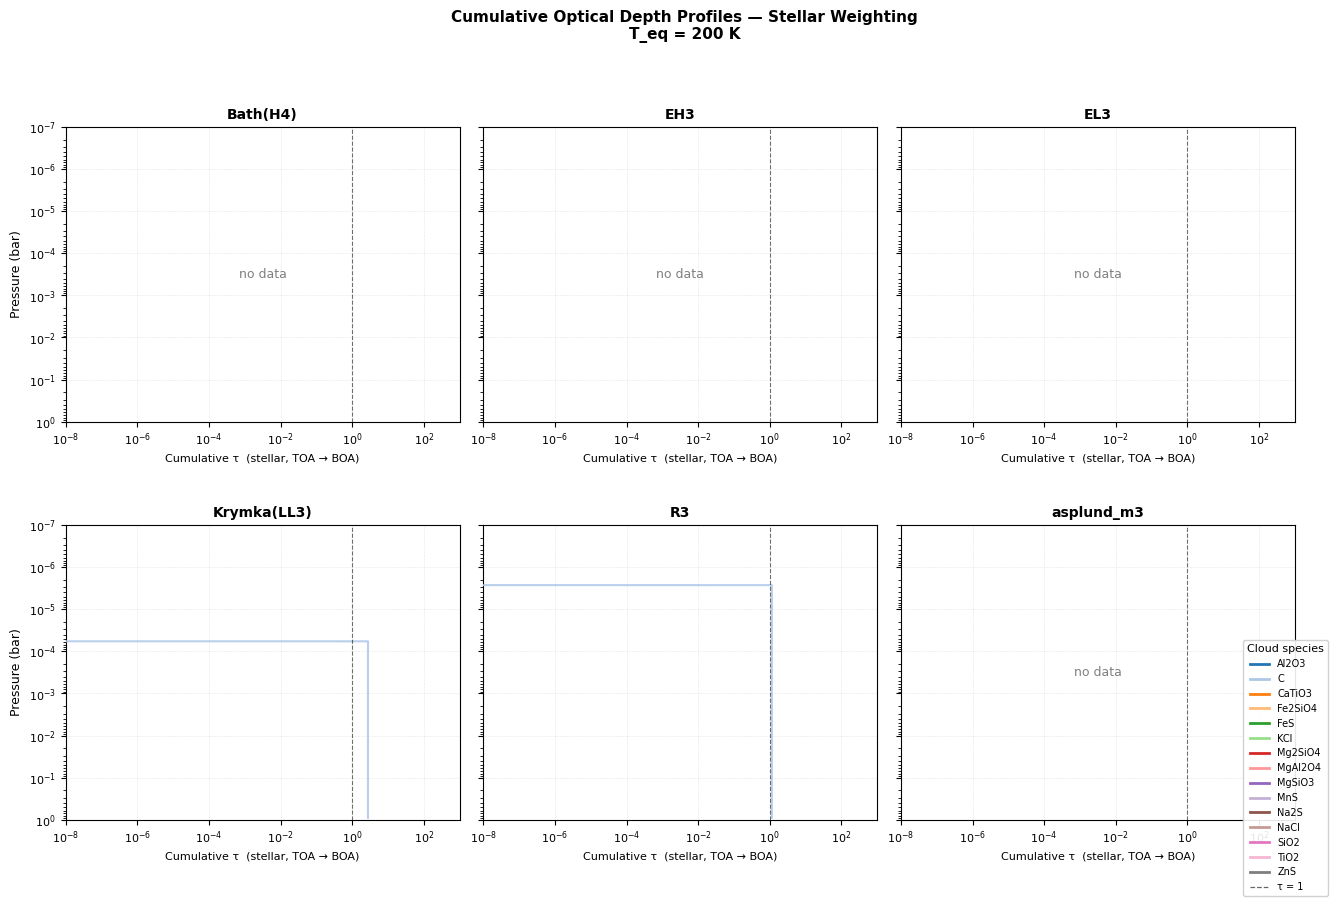

Saved tau_stellar_profiles_200K.pdf


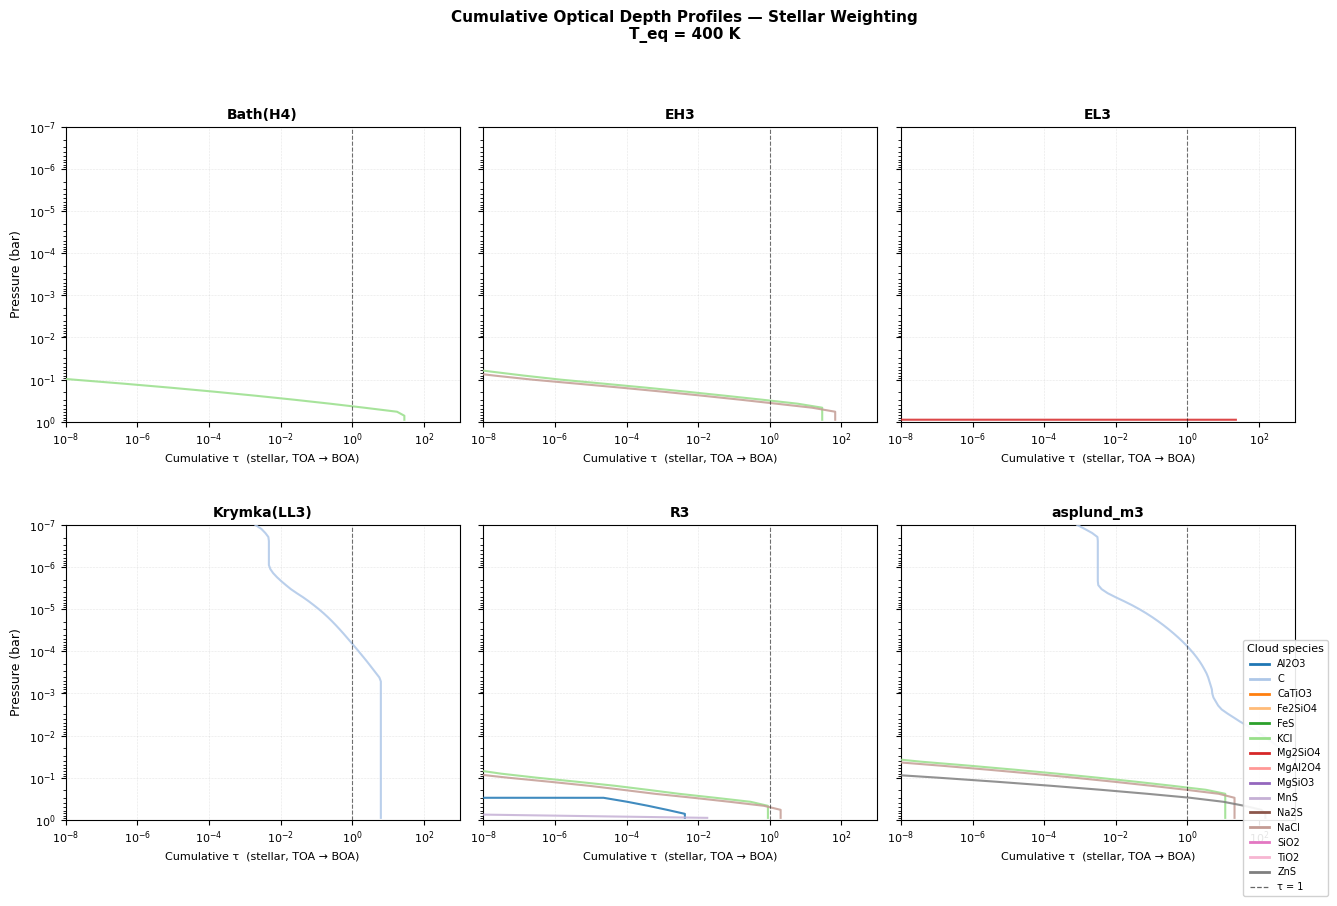

Saved tau_stellar_profiles_400K.pdf


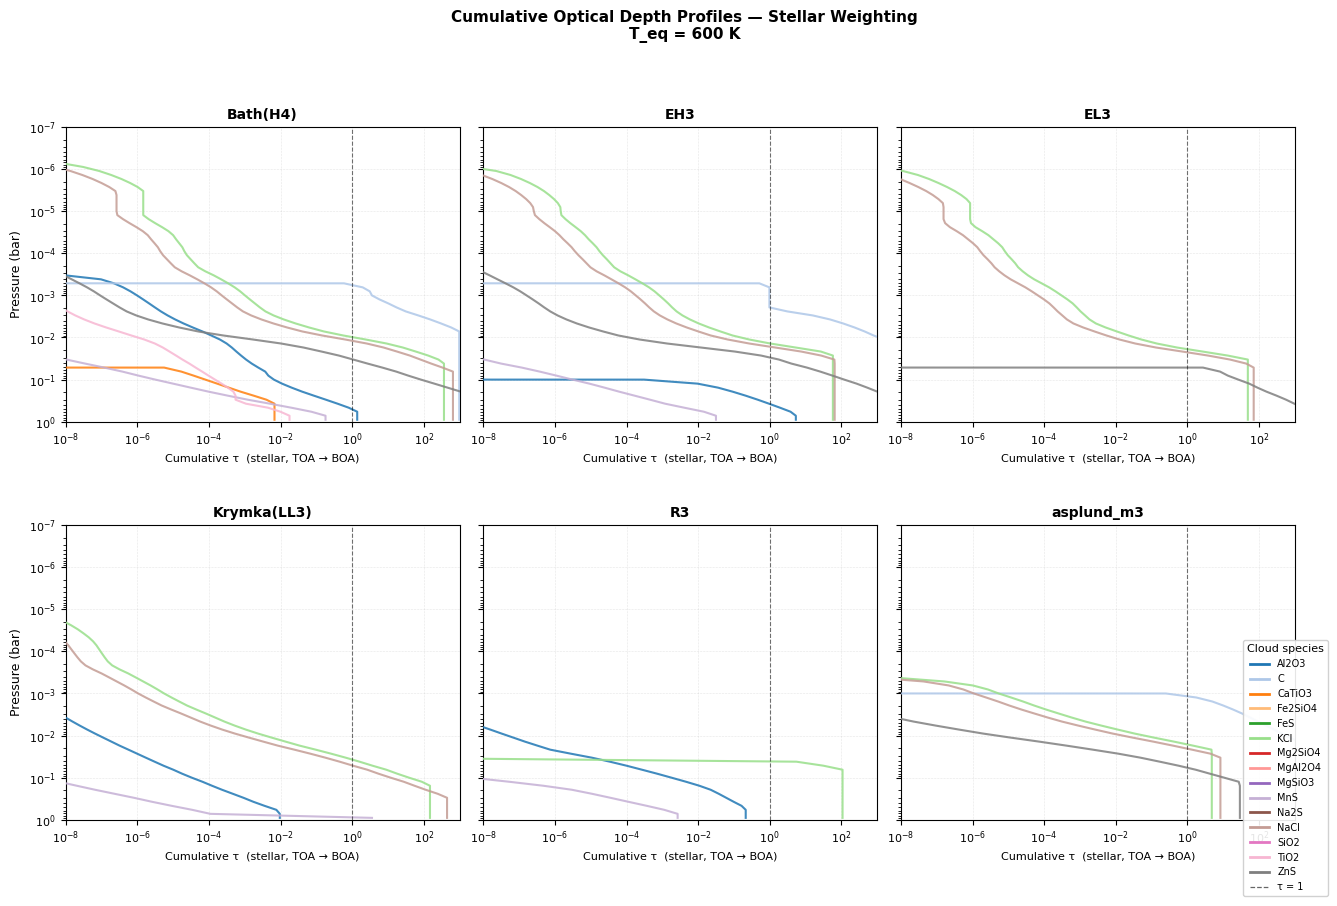

Saved tau_stellar_profiles_600K.pdf


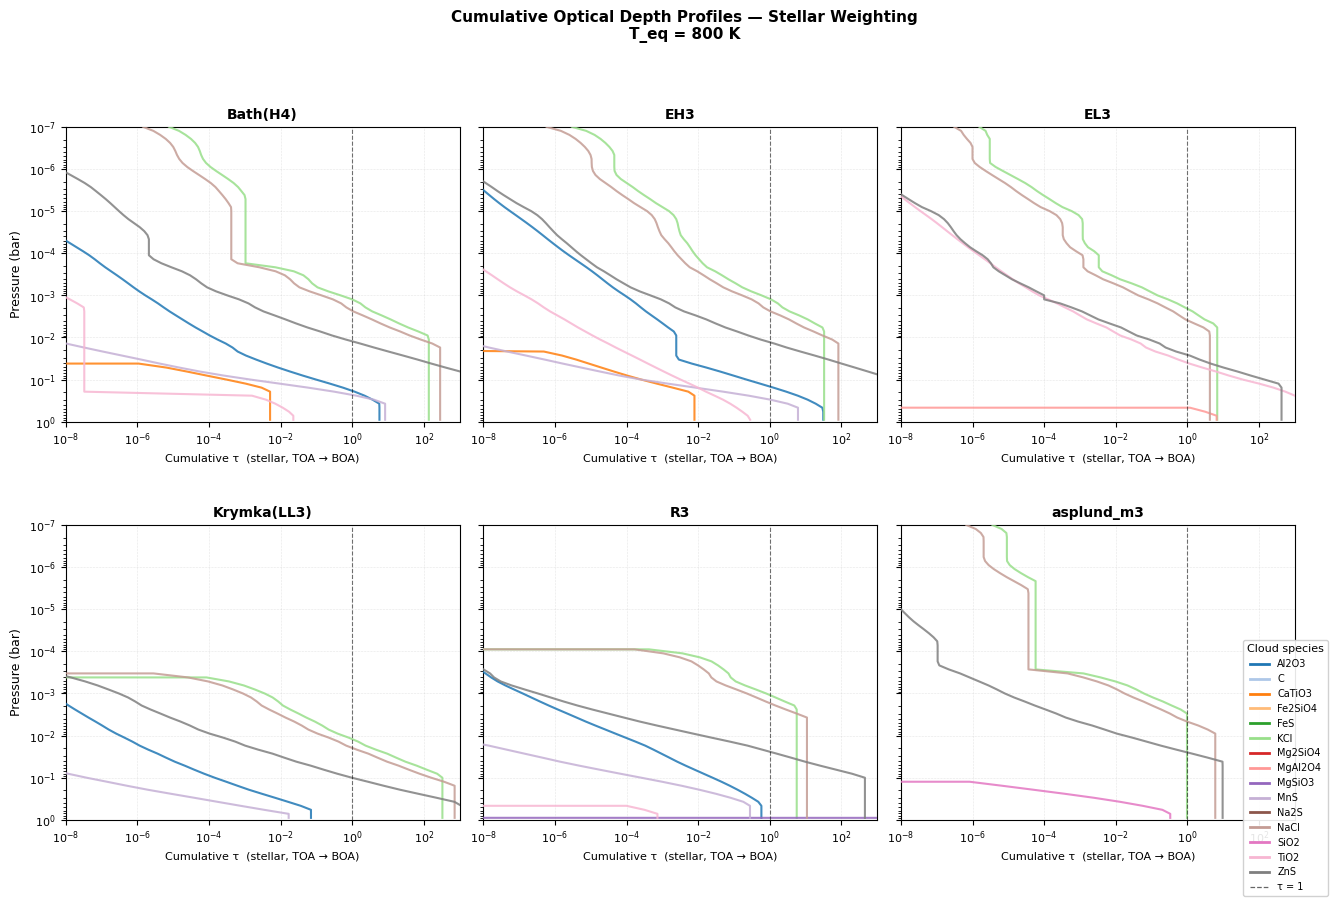

Saved tau_stellar_profiles_800K.pdf


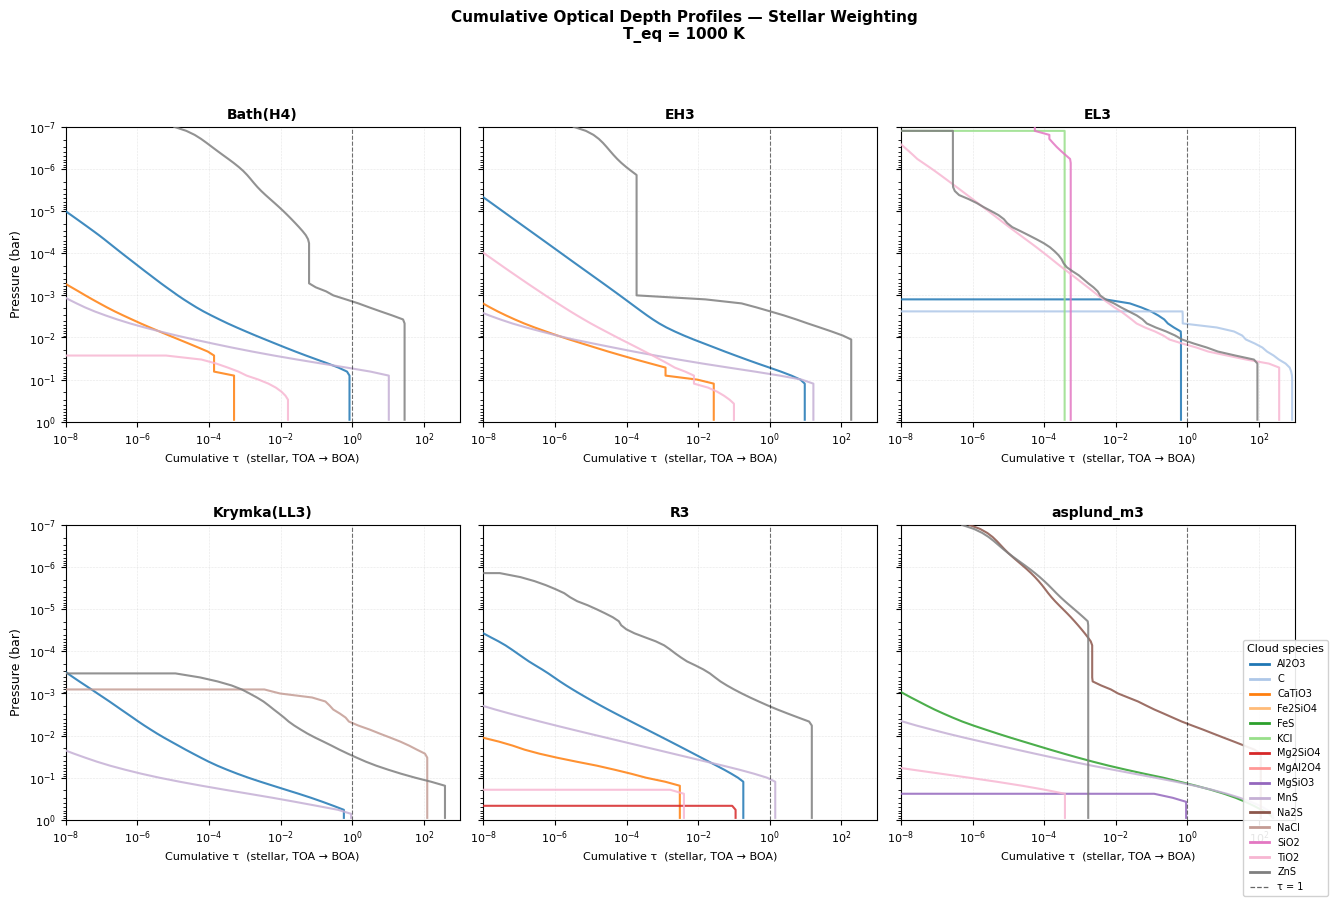

Saved tau_stellar_profiles_1000K.pdf


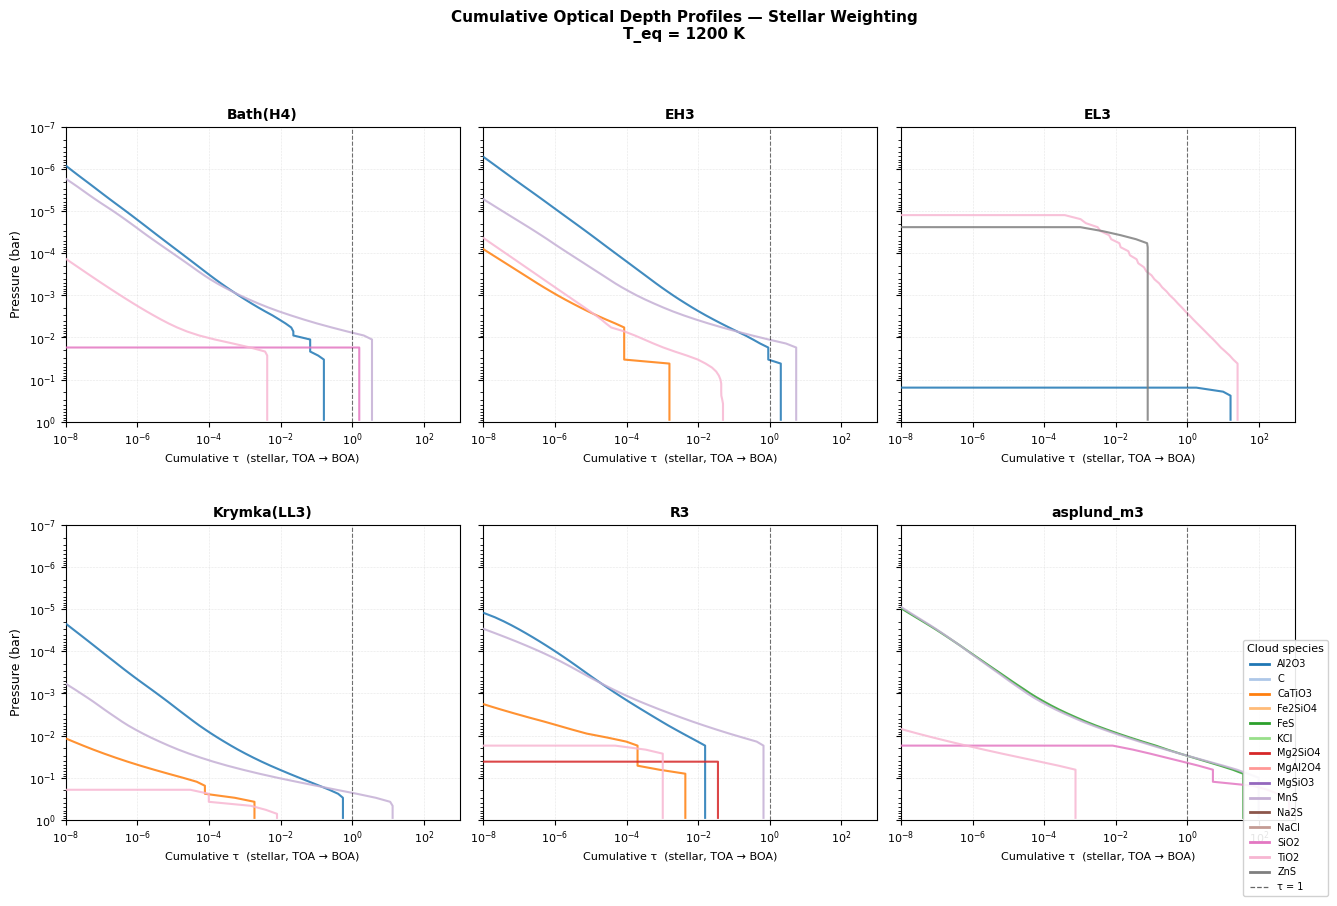

Saved tau_stellar_profiles_1200K.pdf


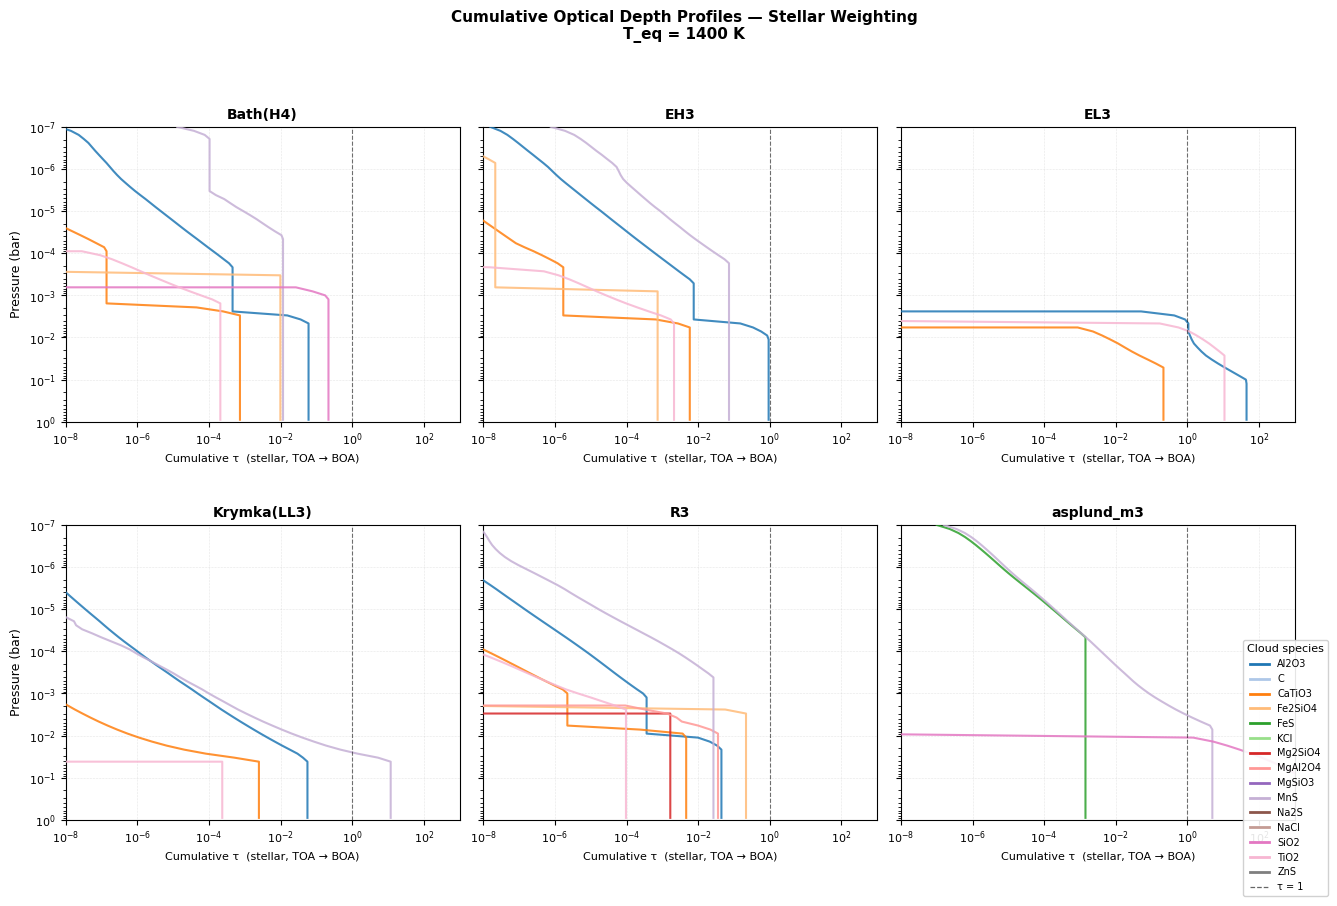

Saved tau_stellar_profiles_1400K.pdf


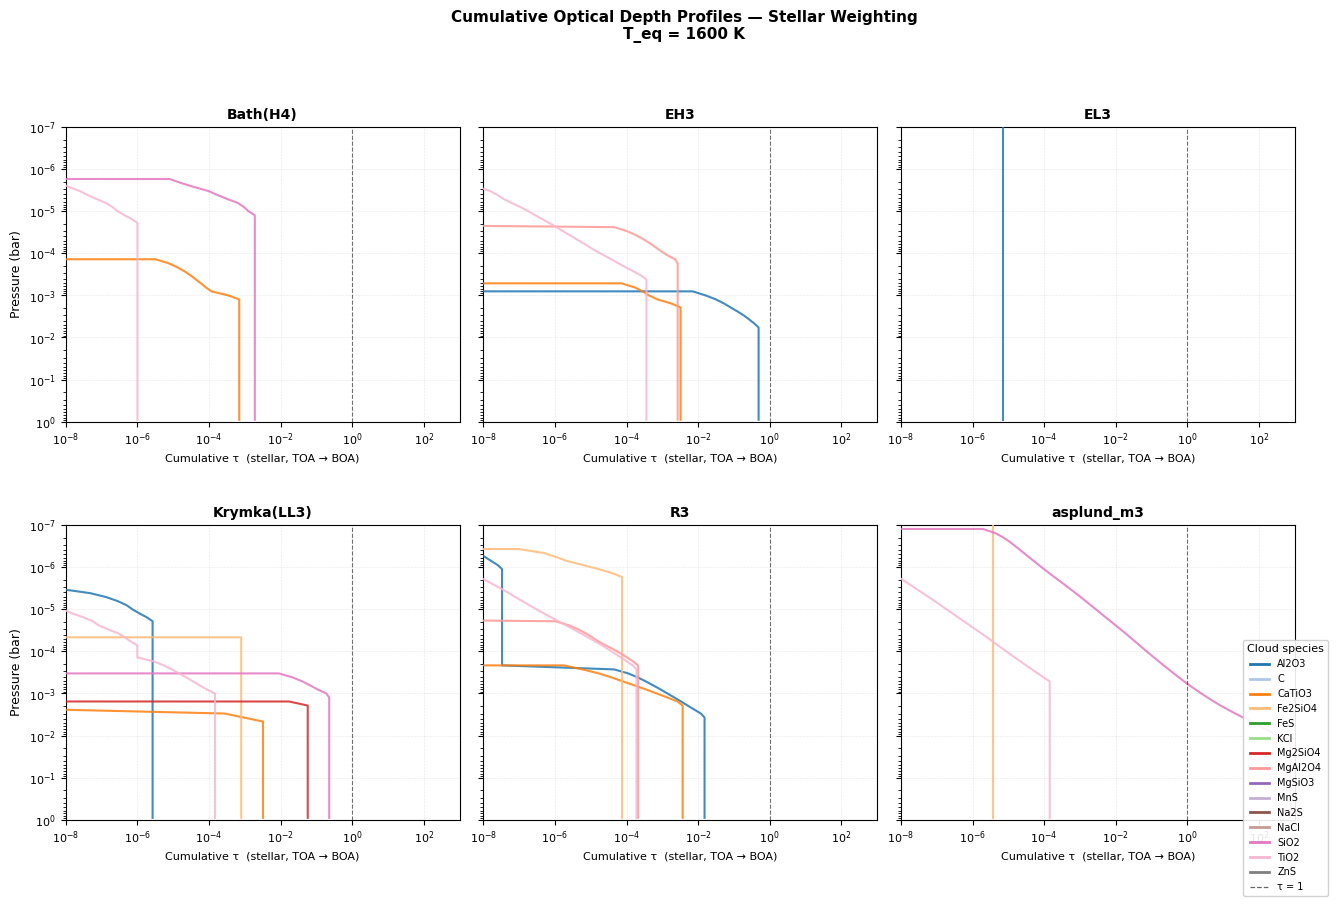

Saved tau_stellar_profiles_1600K.pdf


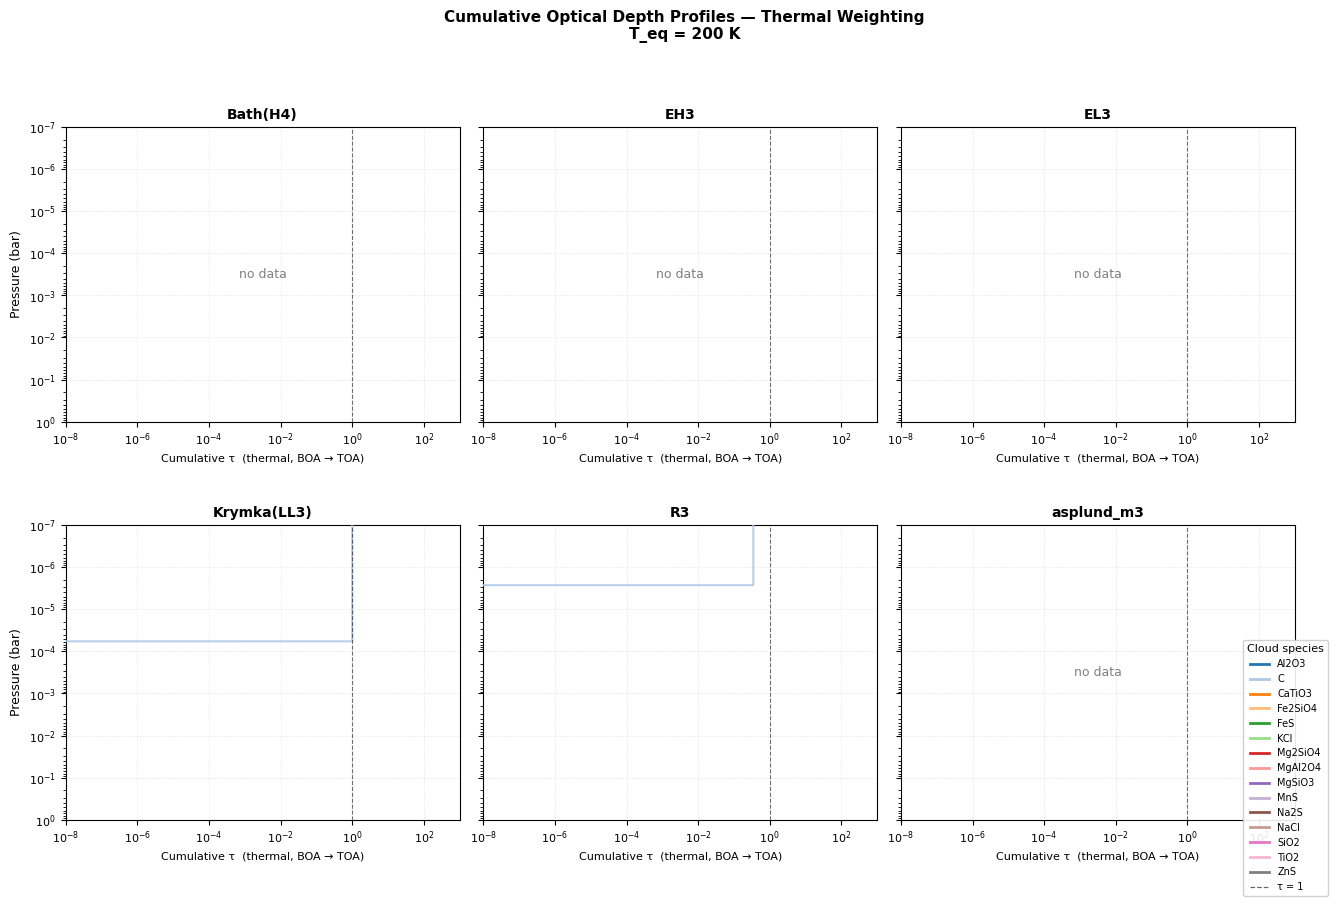

Saved tau_thermal_profiles_200K.pdf


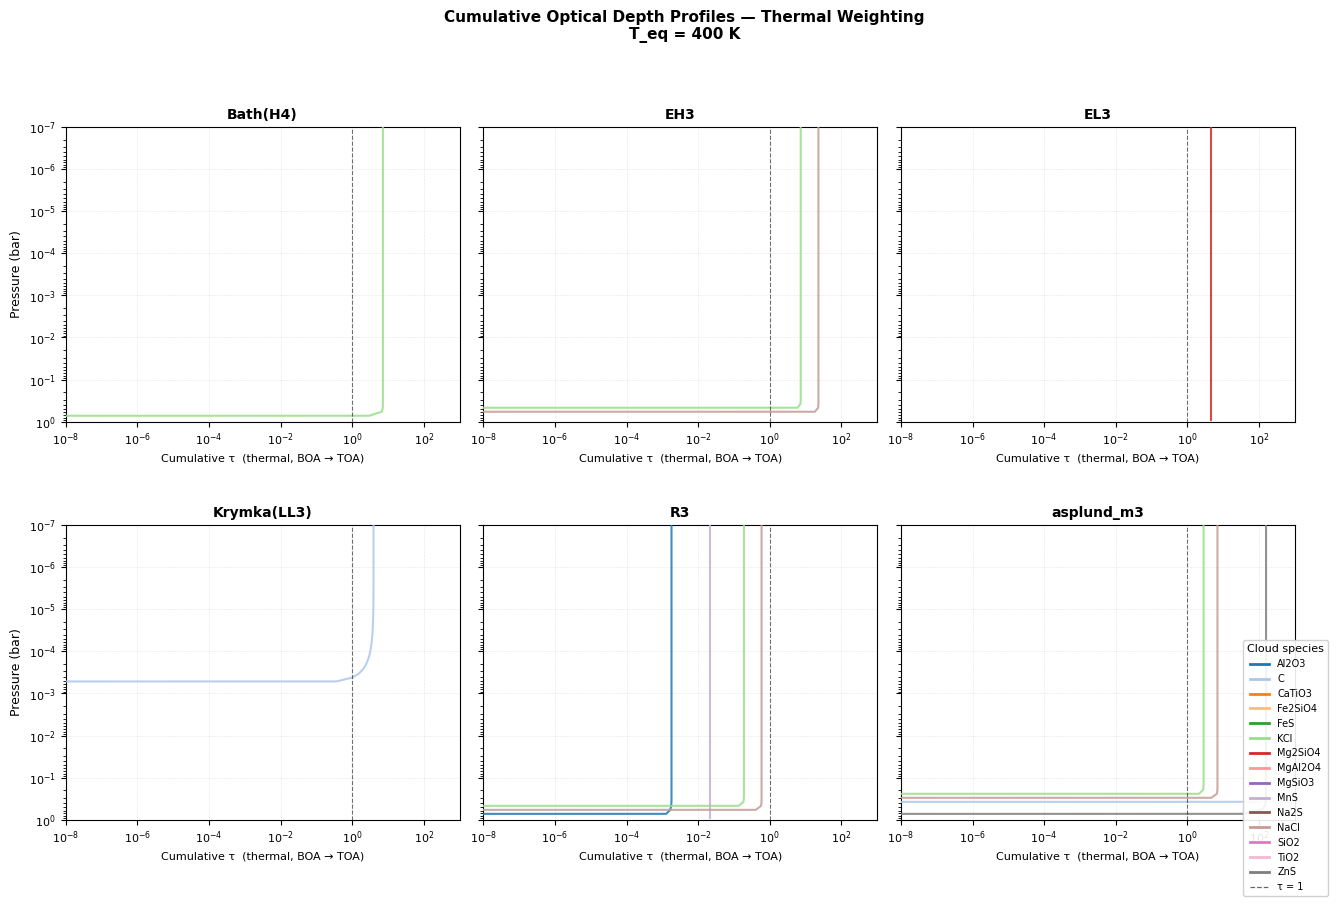

Saved tau_thermal_profiles_400K.pdf


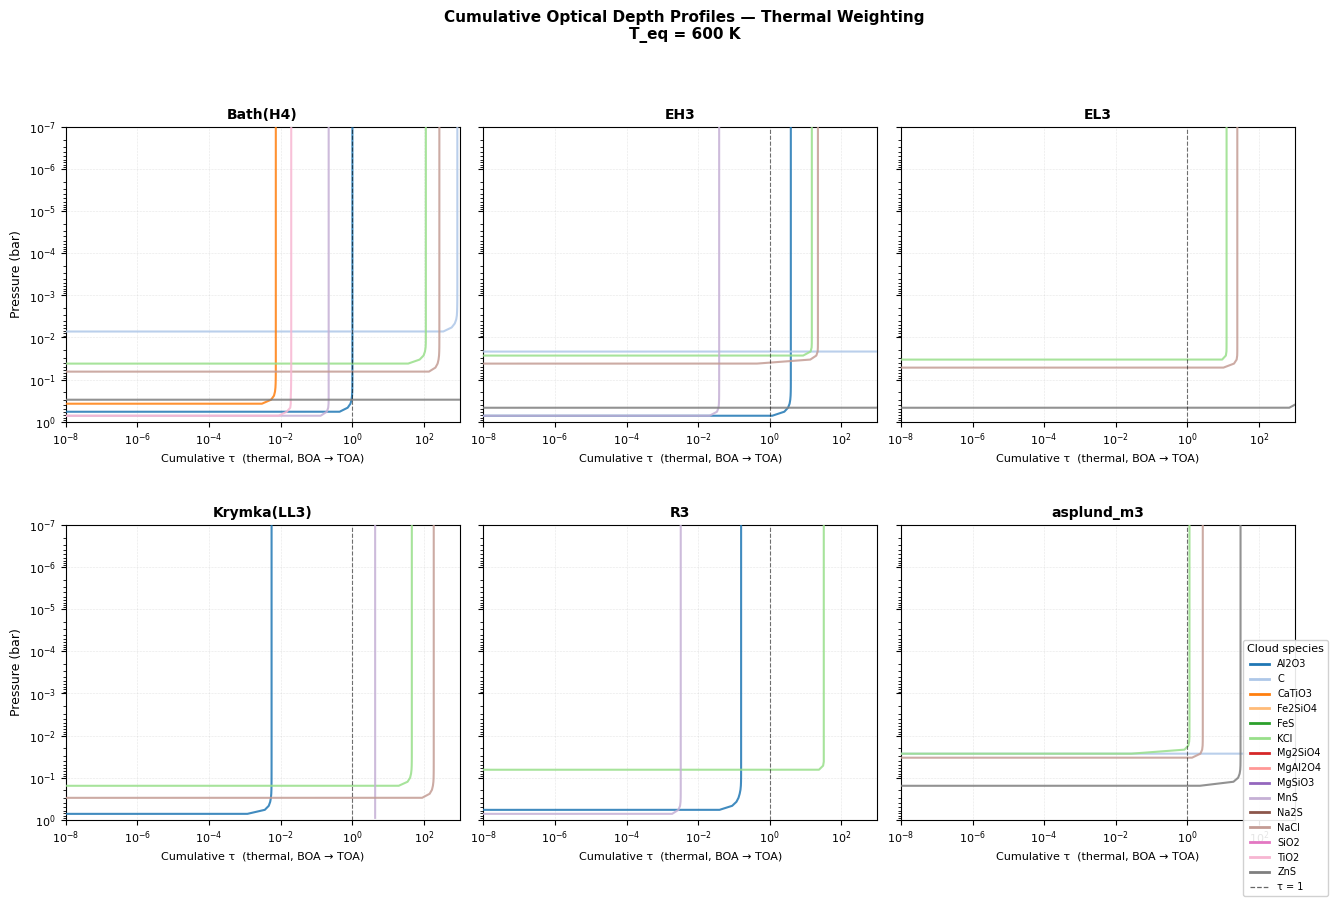

Saved tau_thermal_profiles_600K.pdf


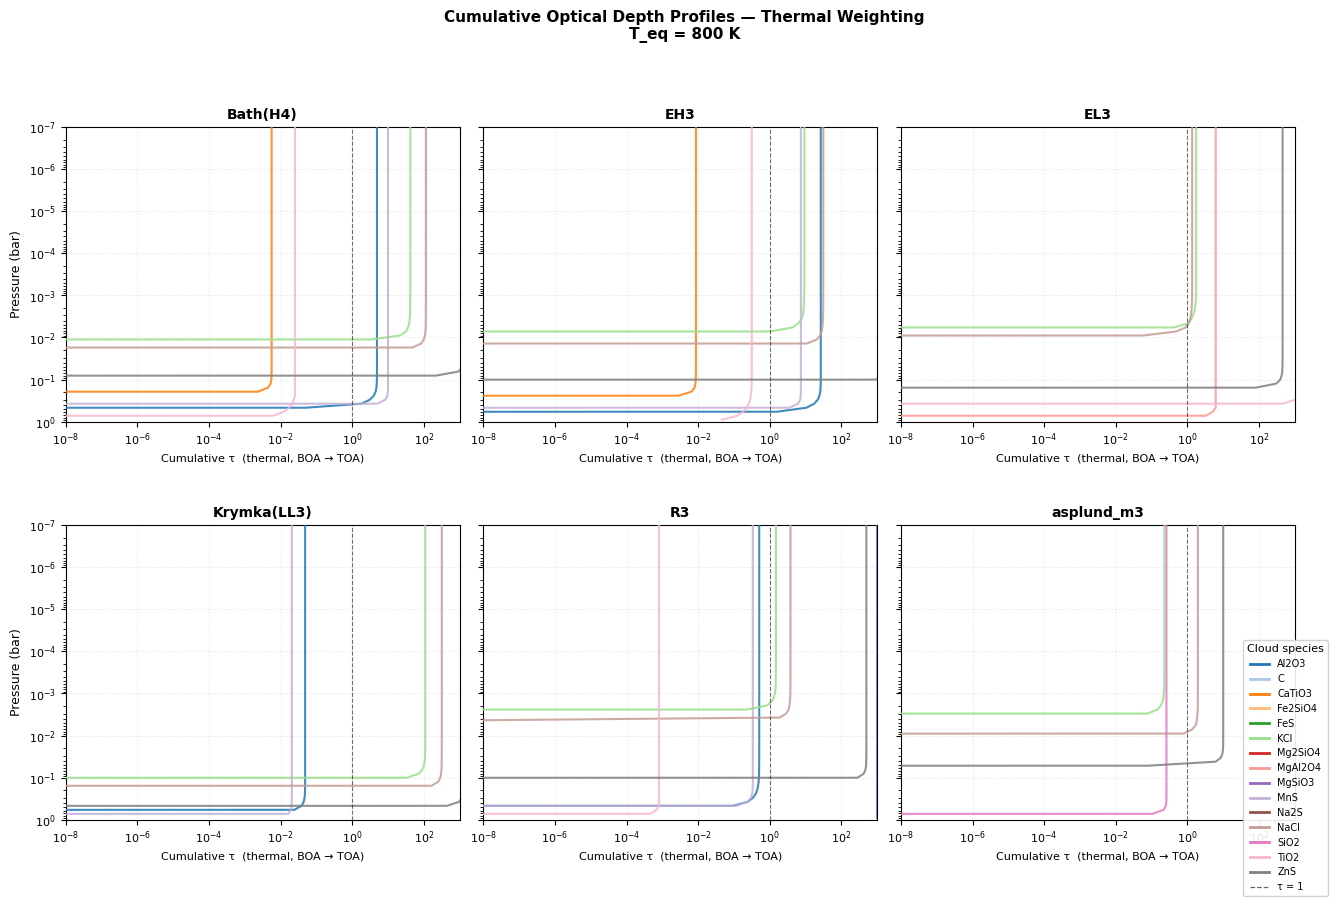

Saved tau_thermal_profiles_800K.pdf


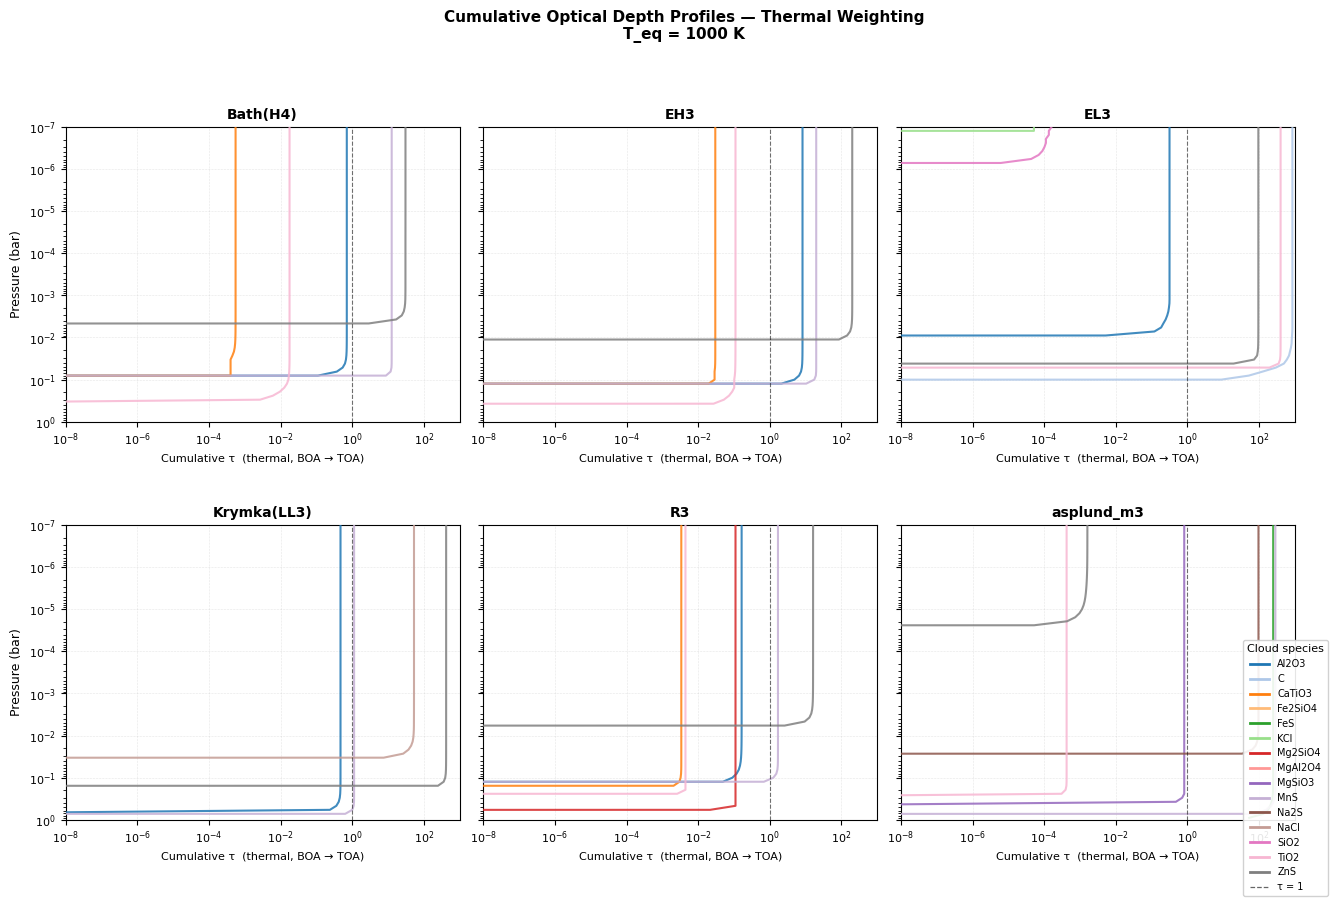

Saved tau_thermal_profiles_1000K.pdf


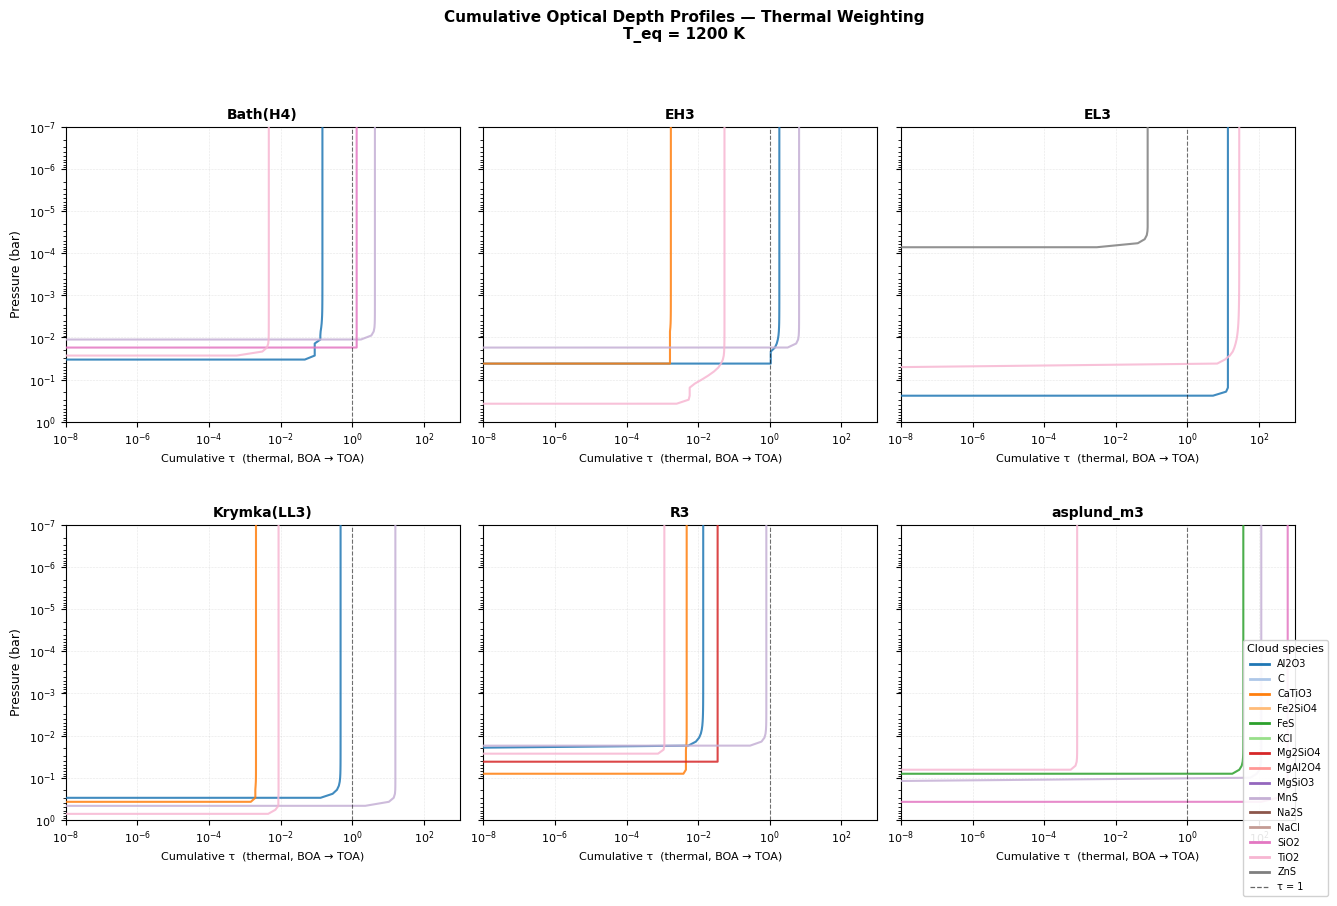

Saved tau_thermal_profiles_1200K.pdf


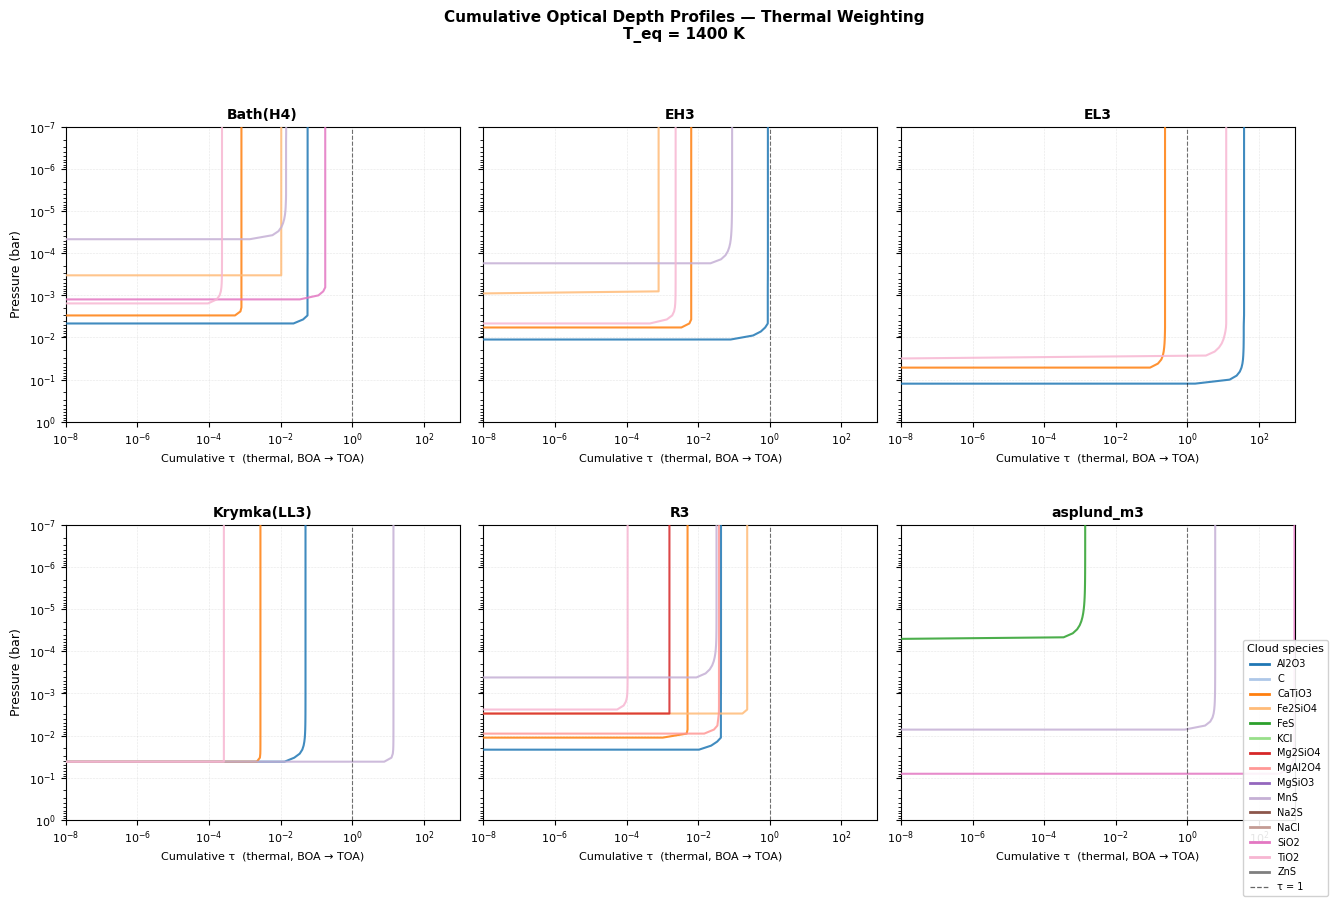

Saved tau_thermal_profiles_1400K.pdf


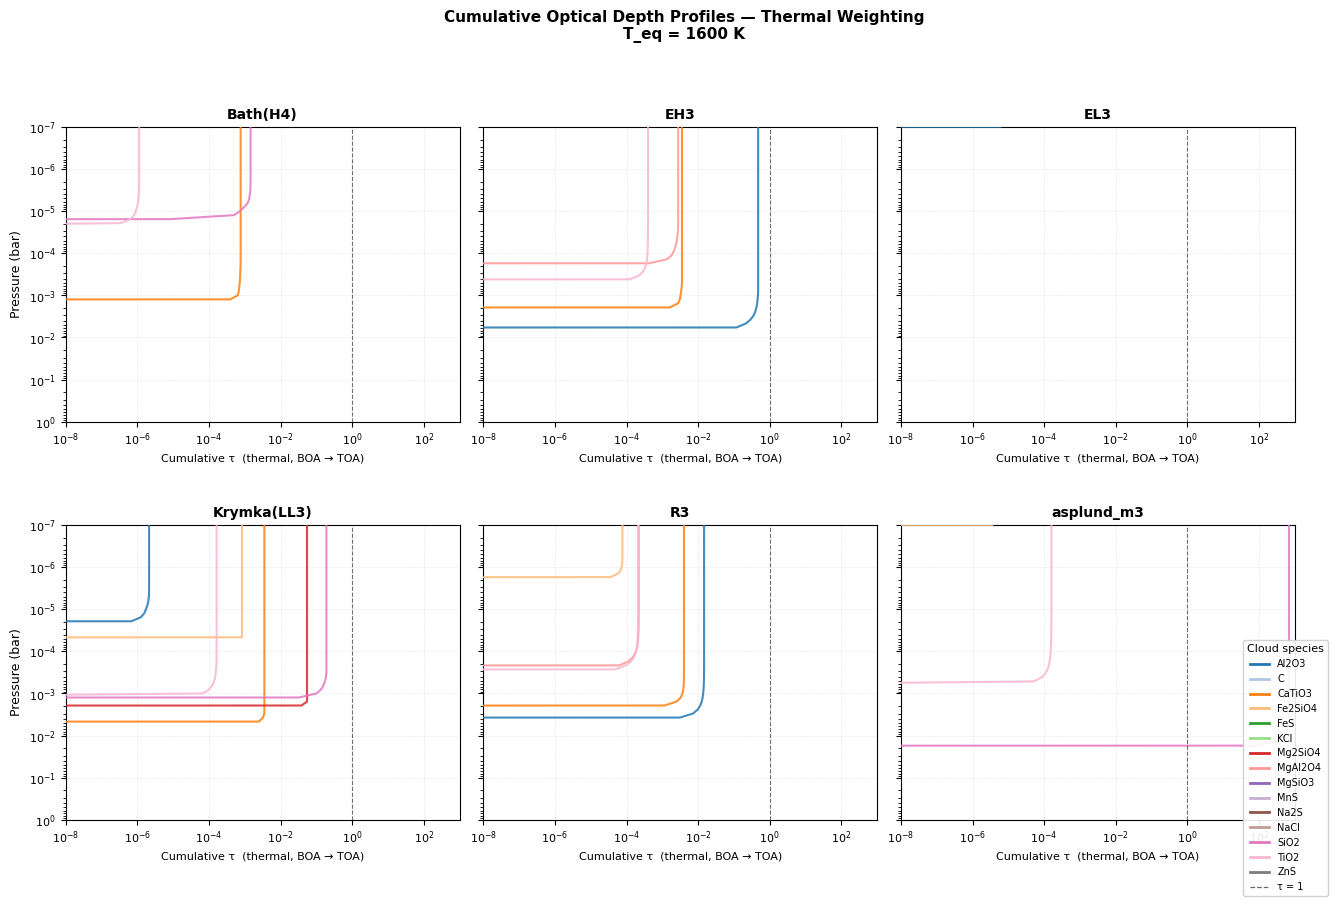

Saved tau_thermal_profiles_1600K.pdf


In [ ]:
for band, tau_key, xlabel, save_prefix in [
    ("Stellar",  "tau_stellar", "Cumulative τ  (stellar, TOA → BOA)",  "tau_stellar_profiles"),
    ("Thermal",  "tau_thermal", "Cumulative τ  (thermal, BOA → TOA)",  "tau_thermal_profiles"),
]:
    NC   = len(COMPOSITIONS)
    ncol = min(3, NC)
    nrow = int(np.ceil(NC / ncol))

    for T_eq in TEMPERATURES:
        # Skip T_eq entirely if no profiles exist for it
        if not any(ALL_TAU_DATA.get((comp, T_eq)) for comp in COMPOSITIONS):
            continue

        fig, axes = plt.subplots(nrow, ncol, figsize=(5.5 * ncol, 4.5 * nrow), sharey=True)
        fig.subplots_adjust(right=0.87, wspace=0.06, hspace=0.35)
        axes_flat = np.array(axes).ravel() if NC > 1 else [axes]

        for extra in axes_flat[NC:]:
            extra.set_visible(False)

        for ax, comp in zip(axes_flat, COMPOSITIONS):
            ax.set_title(comp, fontsize=10, fontweight="bold")
            ax.set_xlabel(xlabel, fontsize=8)
            ax.set_yscale("log")
            ax.set_xscale("log")
            ax.set_ylim(1e0, 1e-7)
            ax.set_xlim(1e-8, 1e3)
            ax.tick_params(axis="both", labelsize=8)
            ax.grid(True, which="major", ls=":", lw=0.4, alpha=0.6)
            ax.axvline(TAU_THRESH, color="k", ls="--", lw=0.8, alpha=0.55, zorder=10)

            data = ALL_TAU_DATA.get((comp, T_eq))
            if data is None:
                ax.text(0.5, 0.5, "no data", transform=ax.transAxes,
                        ha="center", va="center", color="grey", fontsize=9)
                continue

            for sp in CLOUD_SPECIES_IN_DATA:
                if sp not in data:
                    continue
                tau_arr = data[sp][tau_key]
                P_arr   = data["P_layers"]
                ax.plot(tau_arr, P_arr,
                        color=SPECIES_COLOR[sp], linewidth=1.5,
                        alpha=0.85, zorder=3, label=sp)

        for r in range(nrow):
            axes_flat[r * ncol].set_ylabel("Pressure (bar)", fontsize=9)

        # Species legend
        sp_handles = [
            Line2D([], [], color=SPECIES_COLOR[s], linewidth=2, label=s)
            for s in CLOUD_SPECIES_IN_DATA
        ]
        sp_handles.append(
            Line2D([], [], color="k", ls="--", linewidth=0.9, alpha=0.6, label="τ = 1")
        )
        fig.legend(handles=sp_handles, title="Cloud species",
                   loc="lower right", bbox_to_anchor=(0.893, 0.02),
                   fontsize=7, title_fontsize=8, framealpha=0.9)

        fig.suptitle(
            f"Cumulative Optical Depth Profiles — {band} Weighting\n"
            f"T_eq = {T_eq} K",
            fontsize=11, fontweight="bold", y=1.01,
        )

        save_name = f"{save_prefix}_{T_eq}K.pdf"
        # fig.savefig(save_name, bbox_inches="tight", dpi=150)
        plt.show()
        print(f"Saved {save_name}")
        plt.close(fig)


## Figure 2 — Radiatively Dominant Cloud Grid

For each (composition, T_eq) cell, identify which cloud species reaches τ = 1 first:
- **Top grid (stellar):** species with the shallowest (lowest-pressure) τ = 1 crossing,
  as seen by photons descending from TOA.
- **Bottom grid (thermal):** species with the deepest (highest-pressure) τ = 1 crossing,
  as seen by photons rising from BOA.

Cell annotation: species name (top) + τ = 1 crossing pressure (bottom).
Grey "—" = no species reaches τ = 1 in that band.


/home/cwirth/ipykernel_146575/448511307.py:118: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


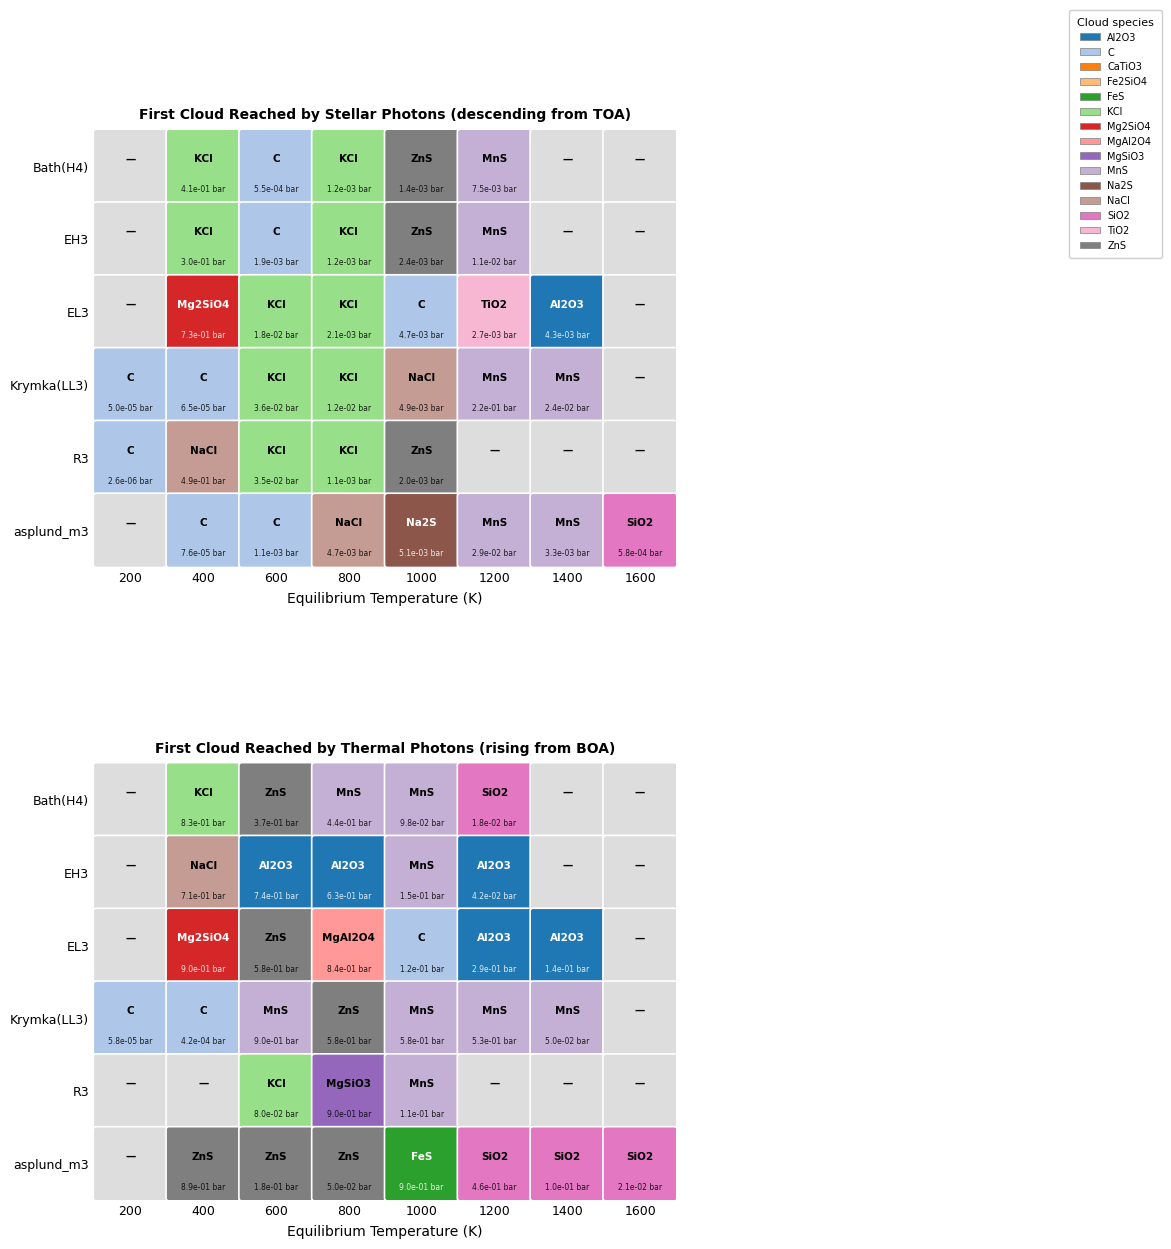

Saved radiative_cloud_grid.pdf


In [25]:
def _dominant_tau1(data, tau_type):
    """Return (species, P_tau1) for the species that reaches τ=1 first.

    For stellar: 'first' = shallowest layer = smallest P_tau1_stellar.
    For thermal: 'first' = deepest layer    = largest  P_tau1_thermal.
    """
    p_key = f"P_tau1_{tau_type}"
    candidates = {
        sp: data[sp][p_key]
        for sp in CLOUD_SPECIES_IN_DATA
        if sp in data and not np.isnan(data[sp][p_key])
    }
    if not candidates:
        return None, np.nan
    if tau_type == "stellar":
        best = min(candidates, key=candidates.__getitem__)   # smallest P = highest altitude
    else:
        best = max(candidates, key=candidates.__getitem__)   # largest P  = deepest
    return best, candidates[best]


# ── Build summary records ─────────────────────────────────────────────────────
records = []
for comp in COMPOSITIONS:
    for T_eq in TEMPERATURES:
        data = ALL_TAU_DATA.get((comp, T_eq))
        row = {"comp": comp, "T_eq": T_eq,
               "sp_stellar": None, "P_stellar": np.nan,
               "sp_thermal": None, "P_thermal": np.nan}
        if data is not None:
            row["sp_stellar"], row["P_stellar"] = _dominant_tau1(data, "stellar")
            row["sp_thermal"], row["P_thermal"] = _dominant_tau1(data, "thermal")
        records.append(row)

summary_df = pd.DataFrame(records)

# ── Plot ─────────────────────────────────────────────────────────────────────
comps = COMPOSITIONS
temps = TEMPERATURES
n_c, n_t = len(comps), len(temps)
comp_idx = {c: i for i, c in enumerate(comps)}
temp_idx = {t: i for i, t in enumerate(temps)}

cell_w, cell_h = 1.55, 0.95
fig_g, (ax_s, ax_t) = plt.subplots(
    2, 1,
    figsize=(cell_w * n_t + 3.0, cell_h * n_c * 2 + 2.5),
    gridspec_kw={"hspace": 0.45},
)

for ax, tau_type, sp_col, p_col, title_txt in [
    (ax_s, "stellar", "sp_stellar", "P_stellar",
     "First Cloud Reached by Stellar Photons (descending from TOA)"),
    (ax_t, "thermal", "sp_thermal", "P_thermal",
     "First Cloud Reached by Thermal Photons (rising from BOA)"),
]:
    ax.set_aspect("equal")
    ax.set_xlim(-0.5, n_t - 0.5)
    ax.set_ylim(-0.5, n_c - 0.5)
    ax.invert_yaxis()

    for _, row in summary_df.iterrows():
        ci = comp_idx[row["comp"]]
        ti = temp_idx[int(row["T_eq"])]
        sp = row[sp_col]
        P  = row[p_col]

        if sp is None or (isinstance(P, float) and np.isnan(P)):
            fc, cell_text, ann_p = "#dddddd", "—", ""
        else:
            fc        = SPECIES_COLOR[sp]
            cell_text = sp
            ann_p     = f"{P:.1e} bar"

        rect = mpatches.FancyBboxPatch(
            (ti - 0.47, ci - 0.47), 0.94, 0.94,
            boxstyle="round,pad=0.04",
            facecolor=fc, edgecolor="white", linewidth=1.2, zorder=1,
        )
        ax.add_patch(rect)

        fc_arr  = np.array(mcolors.to_rgb(fc))
        lum     = 0.299 * fc_arr[0] + 0.587 * fc_arr[1] + 0.114 * fc_arr[2]
        txt_col = "black" if lum > 0.45 else "white"

        ax.text(ti, ci - 0.10, cell_text,
                ha="center", va="center", fontsize=7.5,
                fontweight="bold", color=txt_col, zorder=2)
        if ann_p:
            ax.text(ti, ci + 0.32, ann_p,
                    ha="center", va="center", fontsize=5.5,
                    color=txt_col, alpha=0.85, zorder=2)

    ax.set_xticks(range(n_t))
    ax.set_xticklabels([str(t) for t in temps], fontsize=9)
    ax.set_yticks(range(n_c))
    ax.set_yticklabels(comps, fontsize=9)
    ax.set_xlabel("Equilibrium Temperature (K)", fontsize=10, labelpad=5)
    ax.set_title(title_txt, fontsize=10, fontweight="bold", pad=8)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(length=0)

# Shared legend
legend_handles = [
    mpatches.Patch(facecolor=SPECIES_COLOR[s], label=s,
                   edgecolor="grey", linewidth=0.5)
    for s in CLOUD_SPECIES_IN_DATA
]
fig_g.legend(
    handles=legend_handles,
    title="Cloud species", title_fontsize=8,
    fontsize=7, loc="upper right",
    bbox_to_anchor=(1.02, 0.97),
    framealpha=0.95, borderpad=0.8,
)

plt.tight_layout()
# fig_g.savefig("radiative_cloud_grid.pdf", bbox_inches="tight", dpi=150)
plt.show()
print("Saved radiative_cloud_grid.pdf")
